<a href="https://colab.research.google.com/github/MetodiPetrovski/Robotics-and-ML-Tutor-LLM/blob/main/ML_research_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

url = "https://raw.githubusercontent.com/MetodiPetrovski/Fine-Tuning-Project/main/dataset.json"

data = requests.get(url).json()

In [ ]:
data[-20:]

[{'instruction': 'What is a hyperplane?',
  'output': 'Simple Explanation:\nA hyperplane separates data.\n\nStep-by-Step:\n1. Define boundary\n2. Classify data\n\nExample:\nLine separating classes.\n\nKey Idea:\nDecision boundary.'},
 {'instruction': 'What is robotics perception?',
  'output': 'Simple Explanation:\nPerception helps robots understand surroundings.\n\nStep-by-Step:\n1. Collect sensor data\n2. Process information\n\nExample:\nObject detection.\n\nKey Idea:\nUnderstanding environment.'},
 {'instruction': 'What is robot navigation?',
  'output': 'Simple Explanation:\nNavigation helps robots move safely.\n\nStep-by-Step:\n1. Plan path\n2. Avoid obstacles\n\nExample:\nAutonomous robot movement.\n\nKey Idea:\nSafe movement.'},
 {'instruction': 'What is exploration in RL?',
  'output': 'Simple Explanation:\nExploration means trying new actions.\n\nStep-by-Step:\n1. Try new actions\n2. Learn outcomes\n\nExample:\nTrying new strategies.\n\nKey Idea:\nDiscover better solutions.'},

In [ ]:
!pip install unsloth transformers accelerate peft trl bitsandbytes gradio matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3.2-3B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-unsloth-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


In [ ]:
from datasets import Dataset

def format_example(example):
    return {
        "text": f"<s>[INST] {example['instruction']} [/INST]\n{example['output']}</s>"
    }

dataset = Dataset.from_list(data).map(format_example)

Map:   0%|          | 0/95 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainerCallback

vram_usage = []
peak_vram = []
class VRAMCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        vram = torch.cuda.memory_allocated() / 1e9
        vram_usage.append(vram)
        peak_vram.append(torch.cuda.max_memory_allocated() / 1e9)

In [ ]:
from transformers import TrainingArguments
from trl import SFTTrainer

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 2,
        warmup_steps = 5,
        max_steps = 30,
        learning_rate = 2e-4,
        fp16 = True,
        logging_steps = 1,
        output_dir = "outputs",
    ),
)
trainer.add_callback(VRAMCallback())
trainer.train()


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/95 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 95 | Num Epochs = 2 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,3.370303
2,3.750468
3,3.540605
4,3.545795
5,3.154419
6,3.649712
7,2.924971
8,3.313386
9,2.733694
10,2.322479


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-30/tokenizer_config.json.


TrainOutput(global_step=30, training_loss=2.0740635792414346, metrics={'train_runtime': 46.0352, 'train_samples_per_second': 2.607, 'train_steps_per_second': 0.652, 'total_flos': 146429441875968.0, 'train_loss': 2.0740635792414346, 'epoch': 1.25})

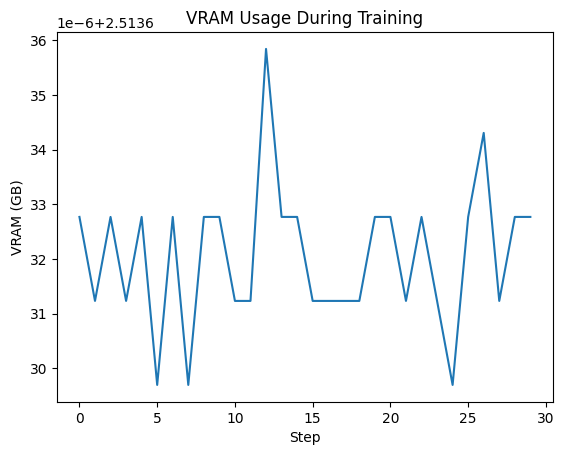

In [ ]:
import matplotlib.pyplot as plt


plt.plot(vram_usage)
plt.xlabel("Step")
plt.ylabel("VRAM (GB)")
plt.title("VRAM Usage During Training")
plt.show()

In [ ]:
def chat_with_model(message, history):
    history = history[-2:]

    conversation = ""

    for user, bot in history:
        conversation += f"[INST] {user} [/INST] {bot} "

    conversation += f"[INST] {message} [/INST]"

    inputs = tokenizer(conversation, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.6,
        top_p=0.9,
        repetition_penalty=1.2,
        eos_token_id=tokenizer.eos_token_id
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response.split("[/INST]")[-1].strip()

In [ ]:
import gradio as gr

demo = gr.ChatInterface(chat_with_model)

demo.launch(share=True)